# Does a Competitive Scene Change Observable Fandom Behavior?

Part of `foundations/esports_vs_game_fandom_signal_model/` — Step 1 of that
brief's task list. Rather than trying to decompose a single viewership
number into "esports-fandom %" vs "game-fandom %" (not reliably answerable
with what this project collects), this notebook tests the comparative
reframe the brief proposes instead: does having an active competitive
scene measurably change a title's observable audience behavior?

**Three-way design**, not two:

1. A basket of non-esports titles from the platform-wide collector — never
   has an organized tournament apparatus at all.
2. The curated titles' own `general`-tier viewership — an esports title,
   but *not* currently tournament-influenced.
3. The curated titles' `primary_official` + `detected_costream`
   viewership — the same titles, tournament-influenced.

If (1) ≈ (2) but (3) looks different, that's real evidence the
competitive apparatus itself is doing the work, not just "being a
notable esports title" in general. If (1) and (2) already differ, that's
a different, also-interesting finding this design can still surface.

**Five titles now, extended 2026-09-16 from the original two.**
`config/channels.yaml` curation started with Counter-Strike and Dota 2;
Street Fighter, VALORANT, and PUBG were added the same day this
extension was built. **The three new titles have real `detected_costream`
data already (tournament/title-text matching doesn't depend on channel
curation) but zero `primary_official` rows so far** — `is_official_broadcast`
is set at capture time, so it only starts accumulating from polls run
*after* a channel is curated, same unbackfillable-going-forward logic as
everything else live in this project. Their tournament-adjacent group
below is entirely `detected_costream` for now; `primary_official` will
fill in as more polls run against the newly-curated channels.


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110


## Refreshing broadcast_tier first

`etl/classify_broadcast_tier.py` is a classification pass, not something
that runs automatically at capture time — new `is_official_broadcast=1`
rows accumulate from `twitch_poll.py` as CS/Dota2's curated channels go
live, but stay `broadcast_tier=NULL` until this script re-runs. Checked
directly before building this notebook: 242,228 previously-unclassified
rows existed, including 119 real `primary_official` rows that had never
been surfaced. Re-run as part of this notebook's own setup, not assumed
current.

In [2]:
import subprocess
result = subprocess.run(
    [sys.executable, str(REPO_ROOT / "etl" / "classify_broadcast_tier.py")],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


0 row(s) to classify (incremental, unclassified only)



## Signal 1 — within-title: tournament-adjacent vs. general viewership

`broadcast_tier`: `primary_official` (curated official channel) and
`detected_costream` (title/date/alias match against a live tournament,
catches co-streamers too) are pooled as "tournament-adjacent" — kept
separate from `general` (everything else).

In [3]:
tier_rows = conn.execute('''
    SELECT title_id, broadcast_tier, channel_id, viewer_count, language
    FROM viewership_snapshots
    WHERE title_id IN ('counter_strike', 'dota2', 'street_fighter', 'valorant', 'pubg')
      AND broadcast_tier IS NOT NULL
''').fetchall()
tier_df = pd.DataFrame(tier_rows, columns=["title_id", "broadcast_tier", "channel_id", "viewer_count", "language"])
tier_df["group"] = tier_df["broadcast_tier"].map({
    "primary_official": "tournament-adjacent",
    "detected_costream": "tournament-adjacent",
    "general": "general",
})

within_title = tier_df.groupby(["title_id", "group"]).agg(
    rows=("viewer_count", "size"),
    distinct_channels=("channel_id", "nunique"),
    avg_viewers=("viewer_count", "mean"),
    median_viewers=("viewer_count", "median"),
    total_viewer_time=("viewer_count", "sum"),
).round(1)

# Top-channel concentration share within each (title, group)
def top_channel_share(g):
    by_channel = g.groupby("channel_id")["viewer_count"].sum()
    return round(by_channel.max() / by_channel.sum() * 100, 1) if by_channel.sum() > 0 else float("nan")

within_title["top_channel_share_pct"] = tier_df.groupby(["title_id", "group"]).apply(top_channel_share, include_groups=False)
within_title


rows  distinct_channels  avg_viewers  \
title_id       group                                                         
counter_strike general               55970              19339         82.1   
               tournament-adjacent    1374                211       2098.2   
dota2          general               36267               9213        121.5   
               tournament-adjacent      79                 15        172.6   
pubg           general               19168               5367         49.3   
               tournament-adjacent     161                 55        346.2   
street_fighter general                8580               3142         70.4   
               tournament-adjacent     324                 79        522.0   
valorant       general              117006              41411         47.2   
               tournament-adjacent     503                203        970.1   

                                    median_viewers  total_viewer_time  \
title_id       group                                                    
counter_strike general                         8.0            4597482   
               tournament-adjacent           235.5            2882868   
dota2          general                         9.0            4408243   
               tournament-adjacent            40.0              13638   
pubg           general                         8.0             944247   
               tournament-adjacent           144.0              55736   
street_fighter general                         8.0             604053   
               tournament-adjacent            82.5             169142   
valorant       general                         7.0            5525235   
               tournament-adjacent            76.0             487956   

                                    top_channel_share_pct  
title_id       group                                       
counter_strike general                                6.0  
               tournament-adjacent                   14.5  
dota2          general                                4.2  
               tournament-adjacent                   35.3  
pubg           general                                4.2  
               tournament-adjacent                   35.3  
street_fighter general                                6.0  
               tournament-adjacent                   36.7  
valorant       general                                3.1  
               tournament-adjacent                   26.3

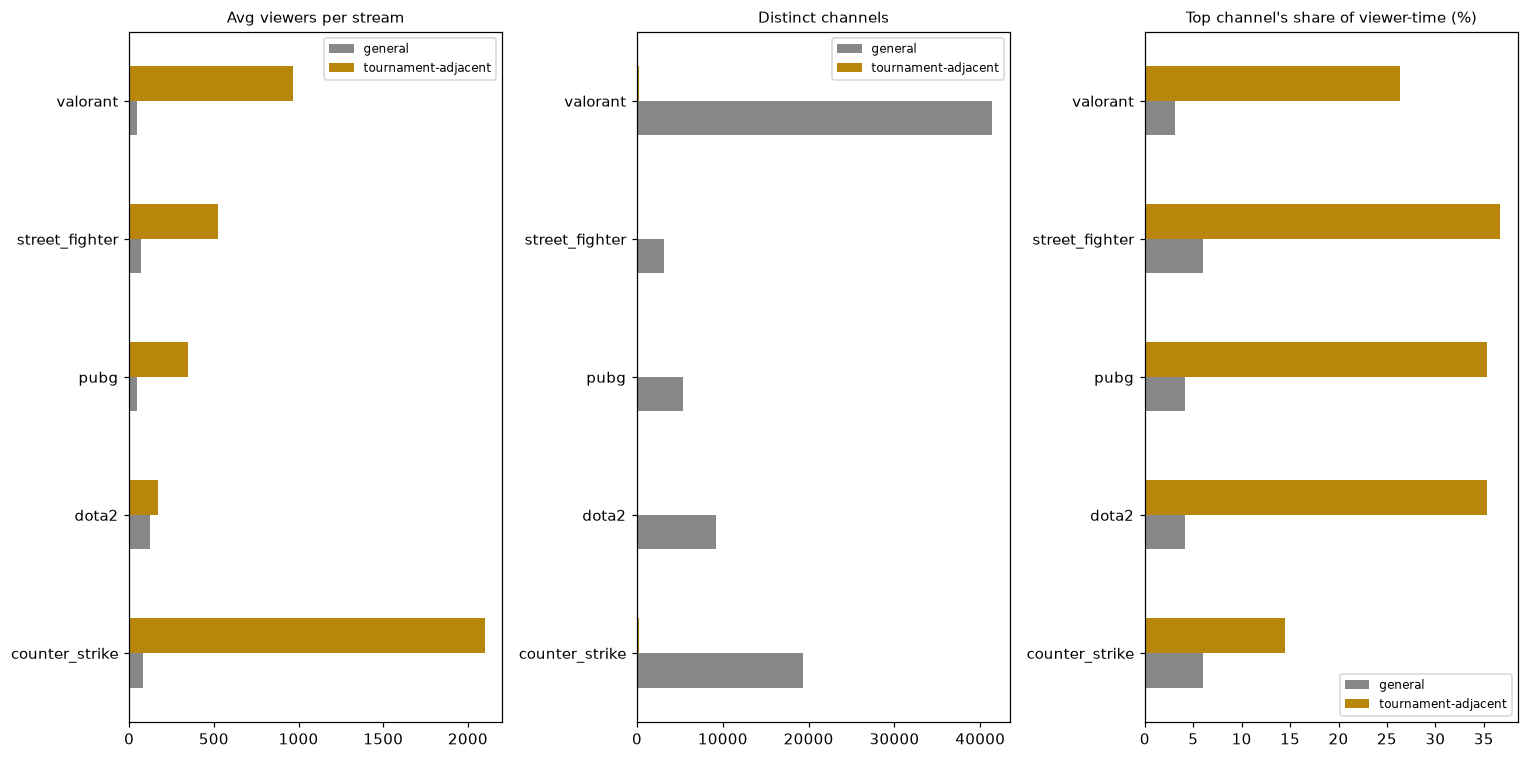

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 7))
plot_df = within_title.reset_index()

for ax, metric, title in zip(
    axes,
    ["avg_viewers", "distinct_channels", "top_channel_share_pct"],
    ["Avg viewers per stream", "Distinct channels", "Top channel's share of viewer-time (%)"],
):
    pivot = plot_df.pivot(index="title_id", columns="group", values=metric)
    pivot = pivot[["general", "tournament-adjacent"]]
    pivot.plot(kind="barh", ax=ax, color=["#888888", "#b8860b"])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(Path.cwd() / "_signal_fig1_within_title.png", dpi=110)
plt.show()


## Signal 2 — the external baseline: non-esports platform-wide viewership

**A first-pass, scoped non-game exclusion list** — `wider_game_fandoms/brief.md`'s
own open item (a real non-game category list) is *not built* project-wide;
this is a narrower list built for this notebook's own comparison, not a
claim to have closed that gap. Built from the actual top `game_name`
values by viewer-time in `platform_viewership_snapshots`, checked live,
not guessed.

**Grand Theft Auto V is excluded from the general non-esports basket
deliberately**, not an oversight — its own nested NoPixel RP-scene
structure (`wider_game_fandoms/gta_launch_case_study/`) is exactly the
kind of internal complexity this baseline needs to *not* have, to stay a
clean "no competitive apparatus, no other known structure" comparison.

In [5]:
NON_GAME_CATEGORIES = {
    "Just Chatting", "IRL", "Music", "Sports", "Slots", "Always On",
    "Virtual Casino", "ASMR", "Art", "DJs", "Special Events", "Talk Shows",
}
EXCLUDED_IDIOSYNCRATIC = {"Grand Theft Auto V"}

baseline_rows = conn.execute('''
    SELECT game_name, channel_id, viewer_count, language
    FROM platform_viewership_snapshots
''').fetchall()
baseline_df = pd.DataFrame(baseline_rows, columns=["game_name", "channel_id", "viewer_count", "language"])
before_n = len(baseline_df)
baseline_df = baseline_df[~baseline_df["game_name"].isin(NON_GAME_CATEGORIES | EXCLUDED_IDIOSYNCRATIC)]
print(f"{before_n} raw rows -> {len(baseline_df)} after excluding {len(NON_GAME_CATEGORIES)} non-game categories and GTA V ({before_n - len(baseline_df)} rows dropped)")

baseline_summary = pd.Series({
    "rows": len(baseline_df),
    "distinct_channels": baseline_df["channel_id"].nunique(),
    "avg_viewers": round(baseline_df["viewer_count"].mean(), 1),
    "median_viewers": round(baseline_df["viewer_count"].median(), 1),
    "top_channel_share_pct": top_channel_share(baseline_df),
})
baseline_summary


1686365 raw rows -> 1411852 after excluding 12 non-game categories and GTA V (274513 rows dropped)


rows                     1411852.0
distinct_channels         525119.0
avg_viewers                   31.5
median_viewers                 5.0
top_channel_share_pct          1.7
dtype: float64

## Three-way comparison

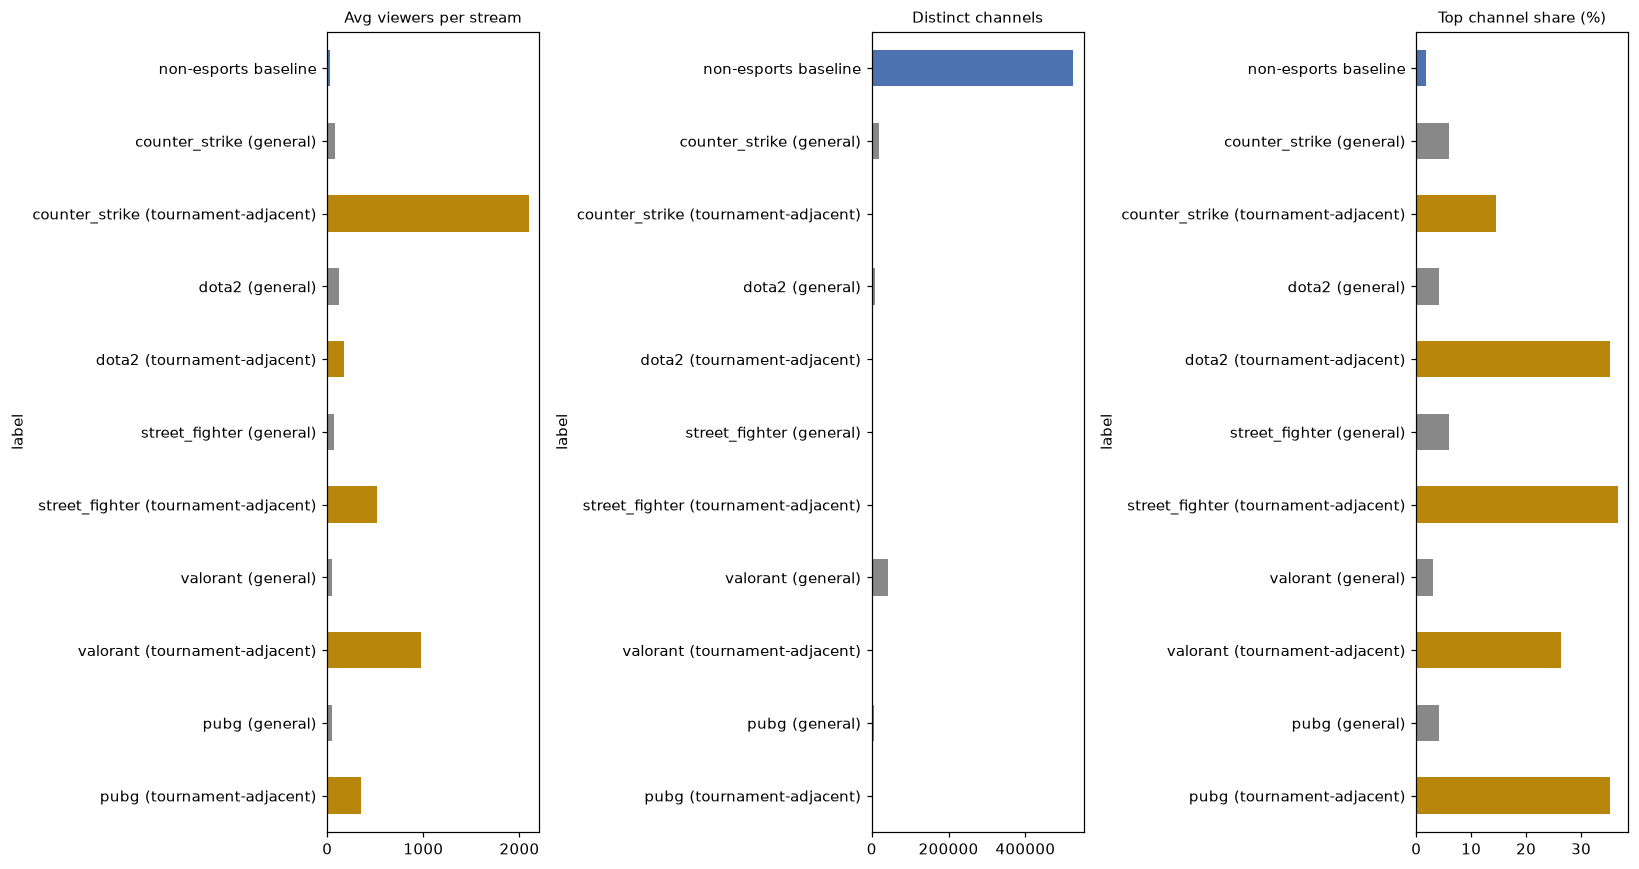

,avg_viewers,distinct_channels,top_channel_share_pct
label,,,
non-esports baseline,31.5,525119.0,1.7
counter_strike (general),82.1,19339.0,6.0
counter_strike (tournament-adjacent),2098.2,211.0,14.5
dota2 (general),121.5,9213.0,4.2
dota2 (tournament-adjacent),172.6,15.0,35.3
street_fighter (general),70.4,3142.0,6.0
street_fighter (tournament-adjacent),522.0,79.0,36.7
valorant (general),47.2,41411.0,3.1
valorant (tournament-adjacent),970.1,203.0,26.3


In [6]:
three_way = within_title.reset_index()
three_way["label"] = three_way["title_id"] + " (" + three_way["group"] + ")"
three_way = three_way.set_index("label")[["avg_viewers", "distinct_channels", "top_channel_share_pct"]]

TITLE_ORDER = ["counter_strike", "dota2", "street_fighter", "valorant", "pubg"]
row_order = ["non-esports baseline"]
for t in TITLE_ORDER:
    row_order += [f"{t} (general)", f"{t} (tournament-adjacent)"]

three_way.loc["non-esports baseline"] = [
    baseline_summary["avg_viewers"], baseline_summary["distinct_channels"], baseline_summary["top_channel_share_pct"],
]
three_way = three_way.reindex([r for r in row_order if r in three_way.index or r == "non-esports baseline"])

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
colors = ["#4c72b0"] + ["#888888", "#b8860b"] * len(TITLE_ORDER)
for ax, col, title in zip(axes, three_way.columns, ["Avg viewers per stream", "Distinct channels", "Top channel share (%)"]):
    three_way[col].plot(kind="barh", ax=ax, color=colors[:len(three_way)])
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(Path.cwd() / "_signal_fig2_three_way.png", dpi=110)
plt.show()
three_way


## Signal 3 — language mix, same three groups

A different dimension of "does behavior change": does the *audience
composition* shift, not just its size/concentration.

In [7]:
def lang_shares(df, top_n=6):
    counts = df.groupby("language")["viewer_count"].sum().sort_values(ascending=False)
    shares = (counts / counts.sum() * 100).round(1)
    return shares.head(top_n)

print("=== non-esports baseline ===")
print(lang_shares(baseline_df))
print()
for (tid, grp), g in tier_df.groupby(["title_id", "group"]):
    print(f"=== {tid} ({grp}) ===")
    print(lang_shares(g))
    print()


=== non-esports baseline ===
language
en    58.0
de     7.9
ru     7.5
es     5.6
fr     5.2
ja     4.9
Name: viewer_count, dtype: float64

=== counter_strike (general) ===
language
ru    47.7
en    17.9
pt    13.5
pl     8.0
es     3.2
fr     1.9
Name: viewer_count, dtype: float64

=== counter_strike (tournament-adjacent) ===
language
ru    60.2
en    27.2
fr     3.0
fi     1.9
pt     1.8
uk     1.4
Name: viewer_count, dtype: float64

=== dota2 (general) ===
language
ru    75.7
en    18.2
pt     3.7
uk     1.0
es     0.4
de     0.3
Name: viewer_count, dtype: float64

=== dota2 (tournament-adjacent) ===
language
ru    78.2
tl     8.1
en     6.8
uk     3.3
th     3.3
pt     0.4
Name: viewer_count, dtype: float64

=== pubg (general) ===
language
ru    32.4
en    22.0
ja    12.9
de     8.8
pt     7.6
zh     3.8
Name: viewer_count, dtype: float64

=== pubg (tournament-adjacent) ===
language
en    42.8
ru    29.1
de    12.0
pt     7.1
zh     2.5
es     1.6
Name: viewer_count, dtype: float64

## Reading the result

**The "esports titles differ from baseline even without a tournament" finding generalizes, not just held for two lucky titles.** Every one of the five curated titles' `general`-tier average viewers beats the 31.5 non-esports baseline — from VALORANT's 47.2 (1.5x) up to Dota 2's 121.5 (3.9x). Being a tracked, notable esports title is a different regime from typical Twitch content across the board, not a quirk of the original two-title check.

**The tournament-adjacent average-viewer effect splits into two real groups, not a spectrum around one number.** CS (25.6x) and VALORANT (20.6x) show a huge jump; Dota 2 (1.4x), Street Fighter (7.4x), and PUBG (7.0x) show a much smaller one. Worth being precise about why, now that there's enough data to actually separate two different mechanisms that were previously easy to conflate:

- **Concentration (top-channel share) does *not* track the same ranking as the average-viewer jump** — CS's concentration ratio (6.0% -> 14.5%, ~2.4x) is the *smallest* of all five titles, even though its average-viewer ratio is one of the largest. Dota 2, Street Fighter, VALORANT, and PUBG all show a much bigger concentration jump (6-8.5x) despite smaller or comparable average-viewer jumps.
- **The likely mechanism, grounded in what's already documented about CS's own scene**: CS has an unusually broad co-stream culture — many creators simultaneously casting the same tournament, each pulling a real audience, rather than viewers funneling into one or two official channels. That inflates CS's tournament-adjacent *average* (lots of big co-streams) without concentrating attention the way a narrower broadcast structure does for the other four titles. Average-viewer-jump and concentration-jump are measuring genuinely different things, not two readings of the same underlying effect — a real refinement on the two-title version of this notebook, which didn't have enough titles to separate them.

**`primary_official` is still zero for all three newly-curated titles** — `config/channels.yaml` curation for Street Fighter/VALORANT/PUBG happened same-day as this extension, and `is_official_broadcast` is capture-time-only, so nothing has accumulated yet. Their tournament-adjacent numbers above are entirely `detected_costream` (title/date/alias matching), a weaker-confidence signal than CS/Dota 2's now-real `primary_official` contribution. Re-run once more polls have landed against the newly-curated channels.

**Language mix produced this run's most striking single finding: Street Fighter's tournament audience is measurably less Japan-centric than its general audience.** General-tier viewing is 75.6% Japanese — an unusually monolingual/regional baseline, much more concentrated than any other title here. During tournament-adjacent windows, Japanese share drops to 41.9% while English (13.4% -> 33.2%), Chinese (2.2% -> 11.4%), and French (5.4% -> 11.2%) all rise sharply. This is the reframe's core question answered as cleanly as this dataset gets: yes, the competitive scene changes observable audience composition, not just its size — for a title whose general fandom looks nothing like its competitive fandom, linguistically.

**VALORANT shows a comparable, if less extreme, version of the same pattern**: general-tier viewing is Chinese-plurality (27.7% zh, next-highest en at 25.6%) — genuinely diverse; tournament-adjacent swings hard toward English (58.5%) with Portuguese and Spanish rising too (15.0%/12.2%), consistent with the curated `valorant_americas` feed carrying most of this window's tournament-adjacent activity among the three curated VCT regions.

**PUBG and Dota 2 show smaller, more title-specific language shifts** — PUBG's tournament window shifts toward English/German (matching its own bio's reference to a live PUBG EMEA Championship at curation time) at the expense of Japanese and Chinese; Dota 2's shift pulls in Filipino/Thai rather than reducing its already-dominant Russian share, unchanged from the two-title version of this check.

## Caveats

- **Single collection window.** Same caveat as the two-title version — a few weeks of hourly polling, not a seasonally-averaged baseline.
- **Three of five titles have zero `primary_official` data** — their tournament-adjacent numbers rest entirely on `detected_costream`'s title-matching heuristic, not confirmed official-channel identity. Re-run this notebook again once real `primary_official` rows accumulate for Street Fighter/VALORANT/PUBG before treating their concentration/average-viewer numbers as final.
- **The non-esports baseline is a first-pass exclusion list**, not the definitive non-game category list `wider_game_fandoms/brief.md` still flags as unbuilt project-wide.
- **`detected_costream` is a title/date/alias match, not a confirmed official-adjacent classification** — reliable for genuine co-streamers (their titles usually name the tournament) but can't rule out an occasional false positive.
